In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [3]:
# Directories
sims_dir = '../../data/sims/sims_1k/'
real_dir = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
names_PS          = [   "v9_70GHz_nside_128",    "v9_94GHz_nside_128",   "v9_100GHz_nside_128",   "v9_143GHz_nside_128"]
names_POBSdebias  = [  "v9_70GHz_POBSdebias",   "v9_94GHz_POBSdebias", "v9_100GHz_POBSdebias", "v9_143GHz_POBSdebias"]
names_LCDMdebias  = [  "v9_70GHz_LCDMdebias",   "v9_94GHz_LCDMdebias", "v9_100GHz_LCDMdebias", "v9_143GHz_LCDMdebias"]

names_Dl_Hayley     = ["Dl70GHz_v9_1%mask.txt", "Dl94GHz_v9_1%mask.txt", "Dl100GHz_v9_1%mask.txt", "Dl143GHz_v9_1%mask.txt"]
names_Cl_LCDMdebias_stdmask = ["Cl70GHz_v9_LCDMdebias_1%mask.txt", "Cl94GHz_v9_LCDMdebias_1%mask.txt", "Cl100GHz_v9_LCDMdebias_1%mask.txt", "Cl143GHz_v9_LCDMdebias_1%mask.txt"]
names_Cl_POBSdebias_stdmask = ["Cl70GHz_v9_obsplanckdebias_1%mask.txt", "Cl94GHz_v9_obsplanckdebias_1%mask.txt", "Cl100GHz_v9_obsplanckdebias_1%mask.txt", "Cl143GHz_v9_obsplanckdebias_1%mask.txt"]
names_Cl_LCDMdebias_commask = ["Cl70GHz_v9_LCDMdebias_common.txt", "Cl94GHz_v9_LCDMdebias_common.txt", "Cl100GHz_v9_LCDMdebias_common.txt", "Cl143GHz_v9_LCDMdebias_common.txt"]
names_Cl_POBSdebias_commask = ["Cl70GHz_v9_obsplanckdebias_common.txt", "Cl94GHz_v9_obsplanckdebias_common.txt", "Cl100GHz_v9_obsplanckdebias_common.txt", "Cl143GHz_v9_obsplanckdebias_common.txt"]

colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [        "-",    "-",     "-",     "-",      "--",      "--",    "--",    "--",]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Planck  = 0
index_Hayley  = 6
Nmaps = len(names_PS)

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "../../data/real/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "../../data/real/COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':15})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  15}

In [5]:
# Same l-range for all Cls
Nside = 128
lmax = 384
ll = np.arange(lmax)

In [6]:
# Load pixel window fct. & beam (smoothing window fct.)
cl_wf = CMBanom.get_cl_wf_factor(Nside)

In [7]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(fn_cl_theory, skiprows=1).T[1])[:lmax]

# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

In [8]:
# Load Planck Cl (begins with l=0) and correct window fcts. and units, shape: (Nmasks, Nmaps, lmax)
cl_PS      = np.array([[np.loadtxt(f"{real_dir}cl_{names_PS[n]}_{names_mask[m]}.txt").T[1]*cl_wf for n in range(Nmaps)] for m in range(Nmasks)])
cl_PS_nwf  = np.array([[np.loadtxt(f"{real_dir}cl_{names_PS[n]}_{names_mask[m]}.txt").T[1] for n in range(Nmaps)] for m in range(Nmasks)])

# Load Hayley's non-debiased Cls
cl_Hayley = np.zeros((4,lmax))
for n in range(4): 
    cl_Hayley[n][2:] = np.loadtxt(real_dir+names_Dl_Hayley[n]).T[1]*2*np.pi/(ll[2:]*(ll[2:]+1))
cl_Hayley_nwf = cl_Hayley/cl_wf

# Load Hayley's debiased Cls
cl_LCDMdebias, cl_POBSdebias = cl_PS.copy(), cl_PS.copy()
for n in range(Nmaps):
    cl_LCDMdebias[1][n][2:] = np.loadtxt(real_dir+names_Cl_LCDMdebias_stdmask[n]).T[1]
    cl_POBSdebias[1][n][2:] = np.loadtxt(real_dir+names_Cl_POBSdebias_stdmask[n]).T[1]
    cl_LCDMdebias[2][n][2:] = np.loadtxt(real_dir+names_Cl_LCDMdebias_commask[n]).T[1]
    cl_POBSdebias[2][n][2:] = np.loadtxt(real_dir+names_Cl_POBSdebias_commask[n]).T[1]

# Compute delta de-bias power spectrum for std mask 
delta_cl_LCDMdebias_stdmask = np.array([cl_LCDMdebias[1][n] - cl_Hayley[n] for n in range(Nmaps)])
delta_cl_POBSdebias_stdmask = np.array([cl_POBSdebias[1][n] - cl_Hayley[n] for n in range(Nmaps)])

# Define the de-biased full-sky cls as: Cl_polspice + delta_cl_debias_stdmask
for n in range(Nmaps):
    cl_LCDMdebias[0][n] += delta_cl_LCDMdebias_stdmask[n]
    cl_POBSdebias[0][n] += delta_cl_POBSdebias_stdmask[n]

cl_LCDMdebias_nwf = cl_LCDMdebias/cl_wf
cl_POBSdebias_nwf = cl_POBSdebias/cl_wf

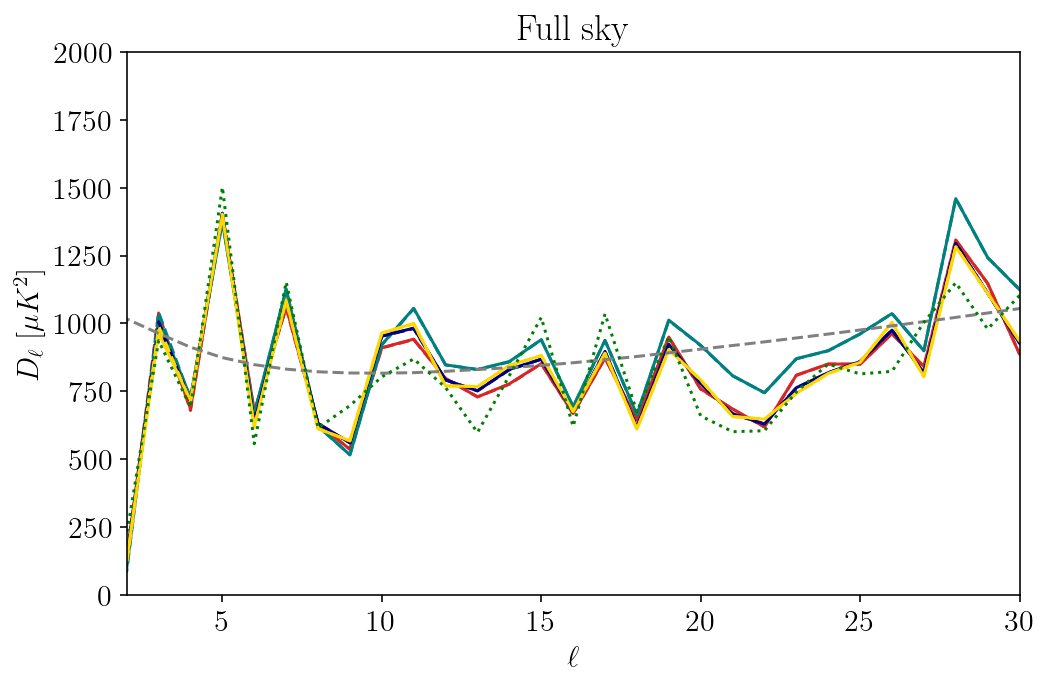

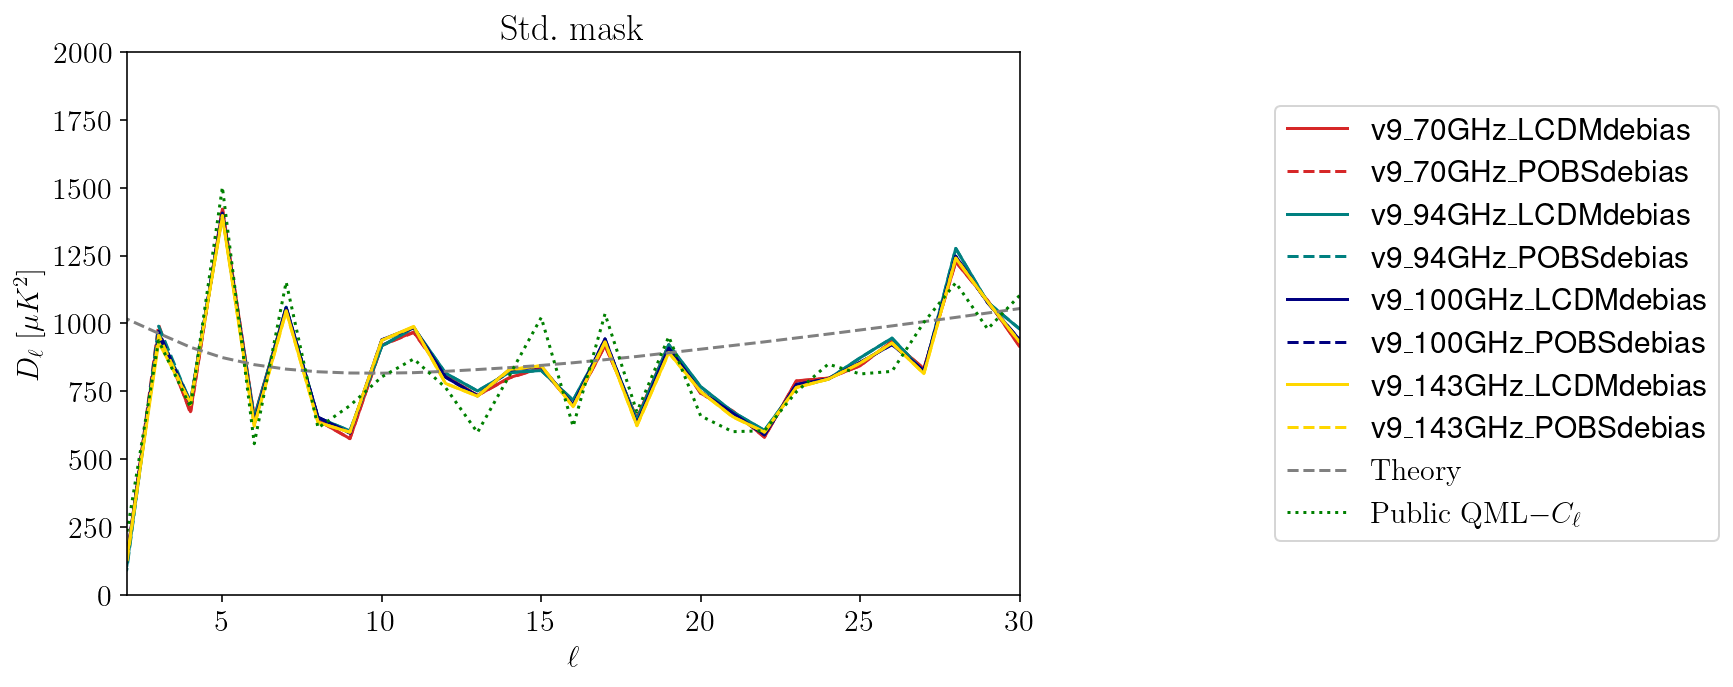

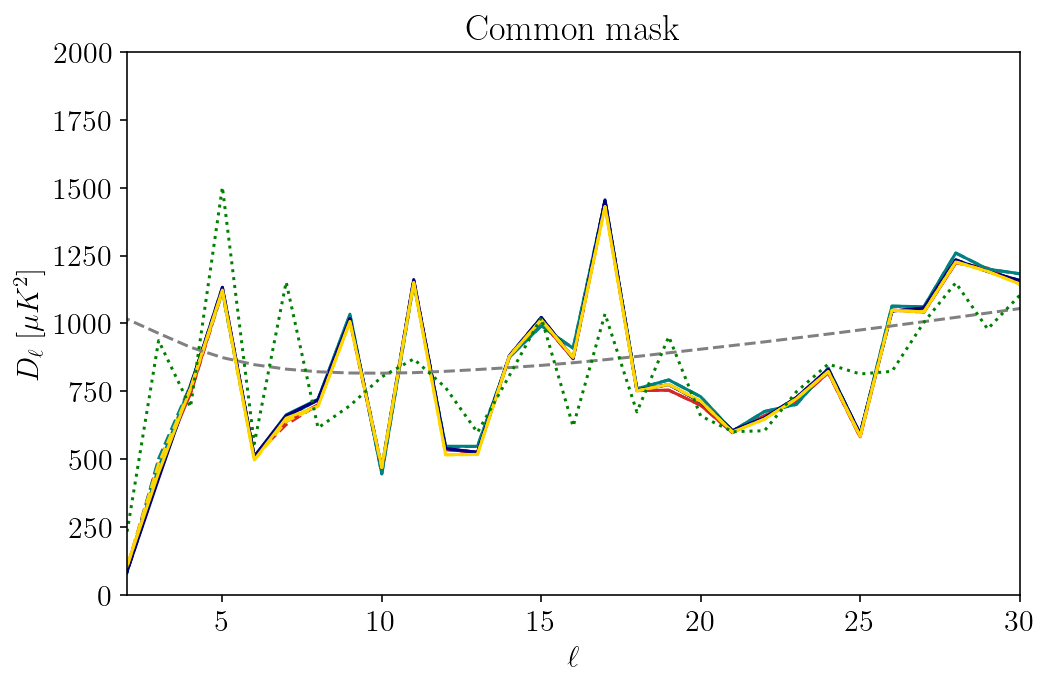

In [9]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(8, 5))
    for n in range(Nmaps): 
        plt.plot(ll, ll*(ll+1)*cl_LCDMdebias[m][n]/(2*np.pi), label=names_LCDMdebias[n], color=colors_Planck[n], ls="-")
        plt.plot(ll, ll*(ll+1)*cl_POBSdebias[m][n]/(2*np.pi), label=names_POBSdebias[n], color=colors_Planck[n], ls="--")
    plt.plot(ll, dl_theory, label=r"$\mathrm{Theory}$", color="grey", ls="--")
    plt.plot(ll, ll*(ll+1)*cl_qml/(2*np.pi), label=label_qml, color=color_qml, ls=":")
       
    plt.ylabel(r"$D_\ell\ [\mu K^2]$")
    plt.xlabel(r"$\ell$")
    plt.xlim(2,30)
    plt.ylim(0,2000)
    plt.title(labels_mask[m])
    #plt.legend(loc="lower right")
    if m==1: plt.legend(loc='center right', bbox_to_anchor=(1.8, 0.5))
    plt.show()

In [14]:
# Save full-sky std-mask de-biased Cl's
for m in range(Nmasks):
    for n in range(Nmaps):
        np.savetxt(f"{real_dir}cl_{names_LCDMdebias[n]}_{names_mask[m]}.txt", np.array([ll, cl_LCDMdebias_nwf[m][n]]).T)
        np.savetxt(f"{real_dir}cl_{names_POBSdebias[n]}_{names_mask[m]}.txt", np.array([ll, cl_POBSdebias_nwf[m][n]]).T)